<a href="https://colab.research.google.com/github/faudhim5-buddy/belajar-ai-30-hari/blob/main/Day_18_Cross_validation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

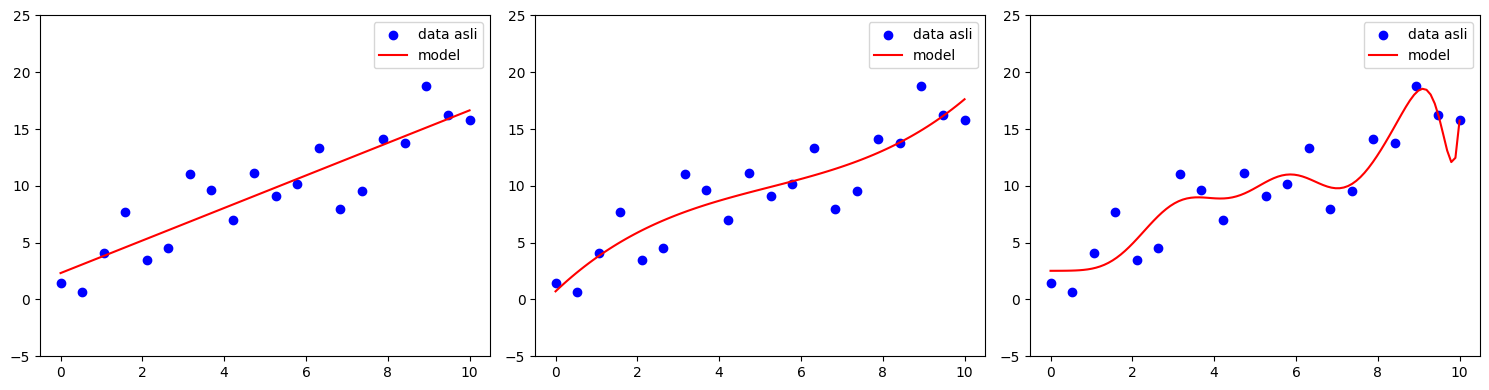

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

np.random.seed(42)
x = np.linspace(0, 10, 20)
y = 2 * x + np.random.normal(0, 3, 20)

x_plot = np.linspace(0, 10, 100).reshape(-1,1)
x = x.reshape(-1,1)

model_under = Pipeline([
    ("poly", PolynomialFeatures(degree=1)),
    ("linear", LinearRegression())
])
model_under.fit(x,y)

model_good = Pipeline([
    ("poly", PolynomialFeatures(degree=3)),
    ("linear", LinearRegression())
])
model_good.fit(x,y)

model_over = Pipeline([
    ("poly", PolynomialFeatures(degree=15)),
    ("linear", LinearRegression())
])
model_over.fit(x,y)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, model, judil in zip(axes,
    [model_under, model_good, model_over],
    ["Undervitting", "Goodfitting", "Overvitting"]):
      ax.scatter(x,y, color="blue", label="data asli")
      ax.plot(x_plot, model.predict(x_plot), color="red", label="model")

      ax.set_ylim(-5, 25)
      ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import numpy as np

data = np.array([
    [160, 50], [165, 55], [170, 60], [175, 65], [180, 70],
    [155, 70], [160, 75], [165, 80], [170, 85], [175, 90],
    [162, 52], [167, 57], [172, 62], [177, 67], [182, 72],
    [157, 72], [162, 77], [167, 82], [172, 87], [177, 92],
])
label = [
    "ideal", "ideal", "ideal", "ideal", "ideal",
    "overweight", "overweight", "overweight", "overweight", "overweight",
    "ideal", "ideal", "ideal", "ideal", "ideal",
    "overweight", "overweight", "overweight", "overweight", "overweight",
]

model = KNeighborsClassifier(n_neighbors=5)
scores = cross_val_score(model, data, label, cv=7)

X_latih, X_uji, y_latih, y_uji = train_test_split(
    data, label, test_size=0.3, random_state=42
)

print("Akurasi tiap fold", scores)
print("Rata-rata fold", scores.mean() *100, "%")
print("Deviasi standard", scores.std() *100, "%")
print()
print("K\tAkurasi Latih\tAkurasi Uji")
print("-" *40)

for k in [1,3,5,7,9,11,13]:
  model = KNeighborsClassifier(n_neighbors=k)
  model.fit(X_latih, y_latih)
  akurasi_latih = accuracy_score(y_latih, model.predict(X_latih))
  akurasi_uji = accuracy_score(y_uji, model.predict(X_uji))
  print(f"K={k}\t{akurasi_latih *100 : .1f}%\t\t{akurasi_uji *100 : .1f}%")


Akurasi tiap fold [1. 1. 1. 1. 1. 1. 1.]
Rata-rata fold 100.0 %
Deviasi standard 0.0 %

K	Akurasi Latih	Akurasi Uji
----------------------------------------
K=1	 100.0%		 100.0%
K=3	 100.0%		 100.0%
K=5	 100.0%		 100.0%
K=7	 100.0%		 66.7%
K=9	 92.9%		 66.7%
K=11	 85.7%		 66.7%
K=13	 57.1%		 33.3%
